# Feedforward Neural Network - Fashion Image Classification

-Basic information about different functions: https://www.tensorflow.org/guide/keras

-Basic image classification: https://www.tensorflow.org/tutorials/keras/basic_classification

-Notebook adapted from: https://www.tensorflow.org/tutorials/keras/classification

### Import required libraries

In [1]:
# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Load our dataset from keras

This is a keras dataset of 60,000 28x28 grayscale images of 10 fashion categories along with a test set of 10,000 images. Keras dataset can be easily downloaded using the keras.datasets object. 

We have 10 class labels: 

0.   T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

**x_train, x_test** gives us integer arrays of grayscale image data with shape (num_samples, 28, 28)

**y_train, y_test** gives us integer arrays of labels (integers in range 0-9) with shape (num_samples,)

Since our class labels gives us integers to represent the class, we need to define the class_names array so we can map the class number to the actual name later on.

source: https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


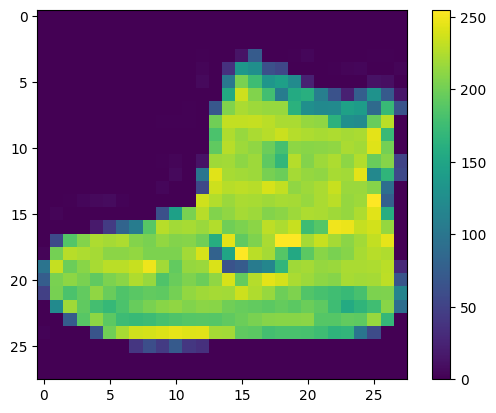

In [2]:
#download data
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

#Make labels correspond to to class names, eg. label 0 is T-shirt
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#look at first image of dataset
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

### Preprocessing

In general for any prediction models, we have to perform some kind of preprocessing.

For neural networks, it isn't necessary to scale them from 0 to 1, but doing so will improve the performance of the model and possibly converge faster.

You can read more about it on: https://machinelearningmastery.com/how-to-improve-neural-network-stability-and-modeling-performance-with-data-scaling/

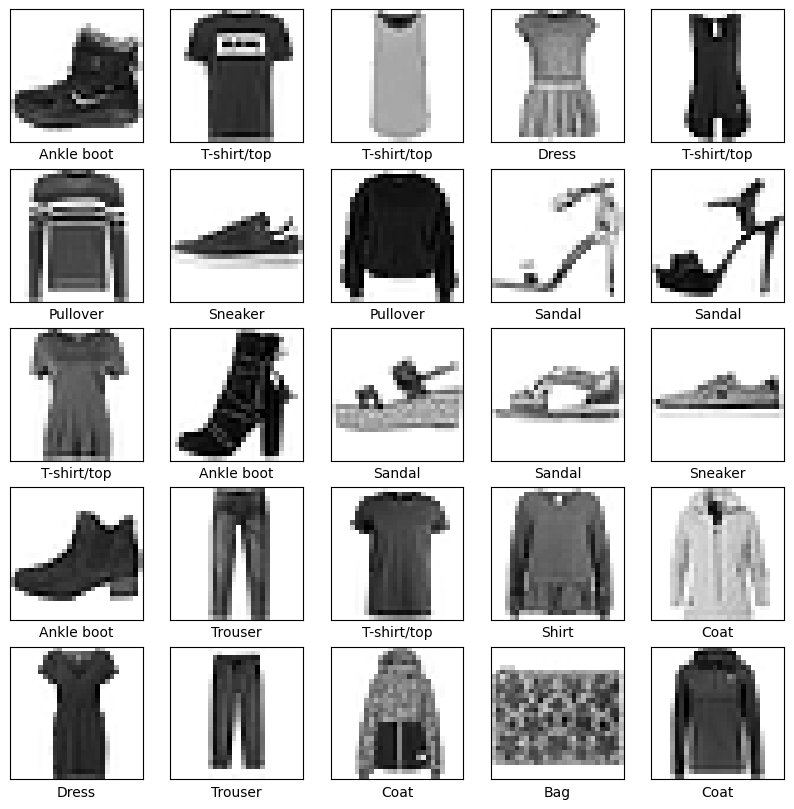

In [3]:
#scale pixel values to between 0 and 1 instead of 0 to 255
train_images = train_images / 255.0
test_images = test_images / 255.0

#verify data is ready to be put in NN
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1) #google "subplot"...first two args are the size of the "matrix of figures"
    #third arg= which position in the matrix am I looking at
    plt.xticks([]) #prevent pyplot from adding "ticks" which are the little bars that say "1,2,3" or "0.1,0.2" on the x axis
    plt.yticks([])# same for y axis
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()


### Define Model Structure

Since our input is an array of size 28 x 28, we will have to specify our input layer by "flattening" the 28 x 28 nodes to 784 nodes. Think of this layer as unstacking rows of pixels in the image and lining them up. This layer has no parameters to learn; it only reformats the data.

After the pixels are flattened, the network consists of a sequence of two tf.keras.layers.Dense layers. These are densely connected, or fully connected, neural layers. The first Dense layer has 128 nodes (or neurons). The second (and last) layer returns a logits array with length of 10. Each node contains a score that indicates the current image belongs to one of the 10 classes.

In [4]:
#set up layers
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

#flatten transforms the 28x28 array into a 784 array

/Users/guansong/CS421Labs/venv/lib/python3.9/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Before the model is ready for training, it needs a few more settings. These are added during the model's compile step:

Loss function —This measures how accurate the model is during training. You want to minimize this function to "steer" the model in the right direction.

Optimizer —This is how the model is updated based on the data it sees and its loss function.

Metrics —Used to monitor the training and testing steps. The following example uses accuracy, the fraction of the images that are correctly classified. Selecting the right metrics for your problem is important - here is a basic article explaining a few metrics for classification problems: https://medium.com/@MohammedS/performance-metrics-for-classification-problems-in-machine-learning-part-i-b085d432082b

In [5]:
#compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

###  Training and evaluating the model

Training the neural network model requires the following steps:

1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
2. The model learns to associate images and labels.
3. You ask the model to make predictions about a test set—in this example, the test_images array.
4. Verify that the predictions match the labels from the test_labels array.

In [6]:
#training the model
model.fit(train_images, train_labels, epochs=5)

#evalutate accuracy of the fitted model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)


#make predictions using model
predictions = model.predict(test_images)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.7806 - loss: 0.6254
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.8584 - loss: 0.3870
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 563us/step - accuracy: 0.8765 - loss: 0.3375
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - accuracy: 0.8838 - loss: 0.3183
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step - accuracy: 0.8899 - loss: 0.2968
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - accuracy: 0.8796 - loss: 0.3381
Test accuracy: 0.8791999816894531
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step


Note that by default the values printed by the fit method are accuracy and loss on the training set. Here we evaluate the loss on the test set manually. Note that we stopped after a fixed number of epochs, so we only need a test set (no validation procedure in this simple example).

### Visualize predictions

With the model trained, we can visualize our predictions. 

We can observe the first 15 predictions,  Correct prediction labels are blue and incorrect prediction labels are red. The numbers (represented in graph) gives the percentage (out of 100) for the predicted label, and we choose the highest number as our predicted label (sneaker, coat, etc)

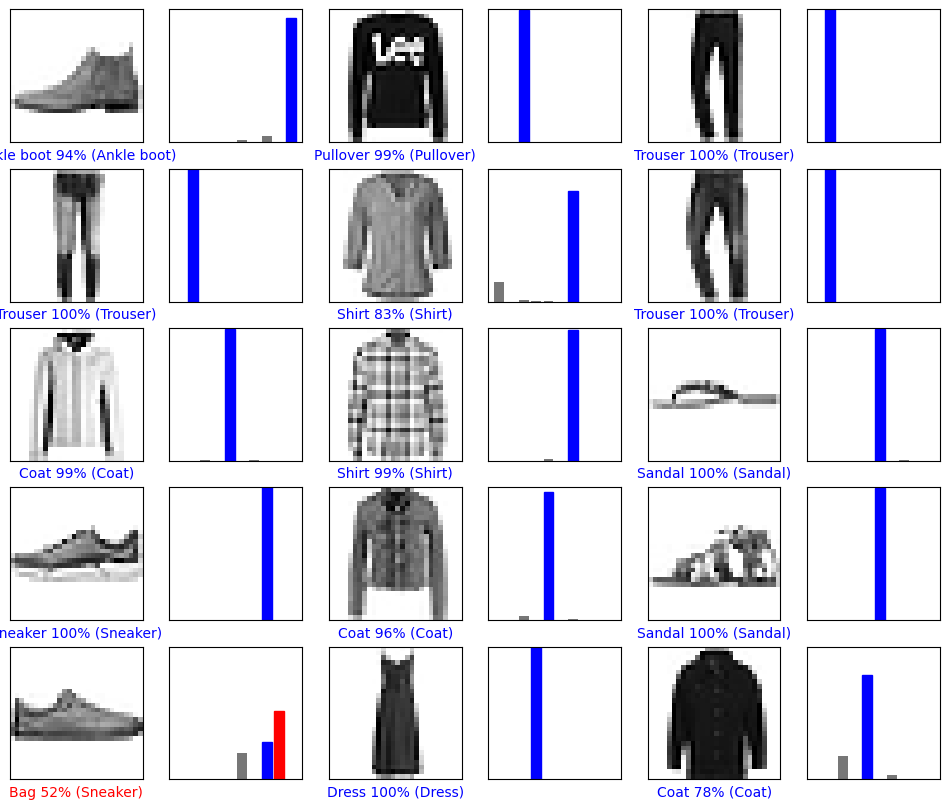

In [7]:
#functions for displaying images and predictions
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  
  plt.imshow(img, cmap=plt.cm.binary)
  
  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'
  
  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label): #this function constructs the bar plots in blue to the right of hte images
  predictions_array, true_label = predictions_array[i], true_label[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)
  
  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue') #if the predicted label is the same as the real label, this line overrides the one above.

# Plot the first X test images, their predicted label, and the true label
# Color correct predictions in blue, incorrect predictions in red
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows)) #the size is in "inches", hence the inexplicable factor two!
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)
plt.show()

Only casual shoes????--

Predicting on a single image

Taking a closer look at a single image: We can observe that ankle boot has the highest number while the next highest labels are a sneaker and sandal, which are still quite similar looking to a 'boot'

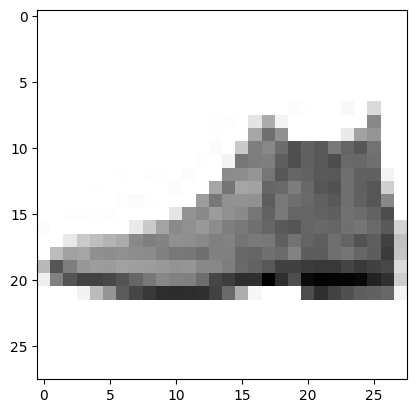

In [8]:
#make prediction about single image
img = test_images[0]
#Prediction on the below image
plt.imshow(img, cmap=plt.cm.binary)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


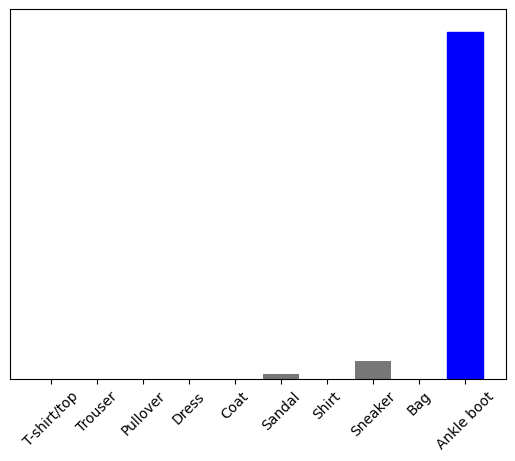

'Ankle boot'

In [9]:
#have to make prediction in a list
img = (np.expand_dims(img,0))
#make prediction of single image
predictions_single = model.predict(img)
plot_value_array(0, predictions_single, test_labels)
plt.xticks(range(10), class_names, rotation=45)
plt.show()
prediction_result = np.argmax(predictions_single[0])
class_names[prediction_result]